## Exploring New Emergence of Varianty
**Author:** Karen Guzman

**Description:** Exploring different values of susceptible, infected, and recovered individuals with two variants. We introduce the new variant's transmission rate, beta2.


**Date:** 6/19/2026

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../models')
#imports
import numpy as np
import matplotlib.pyplot as plt
import new_emergence as ne

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


**Exploring difference scenarios**

Scenario 1 - Emergence, replacement, and takeover by variant 2

Peak of Strain 1: 52.793636616675535 at time 10.521042084168338
Peak of Strain 2: 203.59338756452482 at time 172.2444889779559
Total infected with Strain 1: 468.2498097642926
Total infected with Strain 2: 518.2398844669253


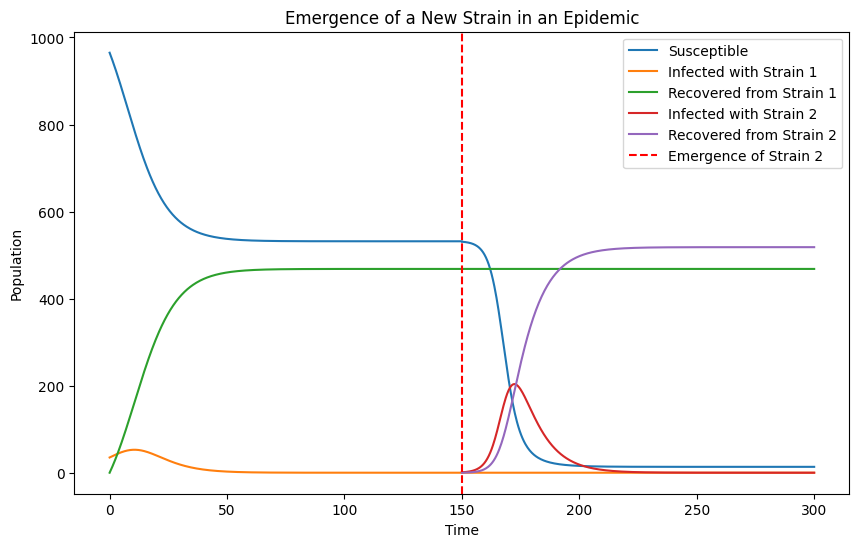

In [4]:
#where variant 2 emerges and takes over
params = [0.42, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=150)

ne.plot_emergence(t, y)

Variant 2 emerges after the first has burned out. Variant 1 $(R_0 = 1.27)$ produces an early wave, infecting about 468 of the population in total. Variant 2 emerged t = 150 at a more transmissible rate $(R_0 = 7.08)$. It infects about 518 people in total. Since each person catches at most one variant, the two strains end up infecting different halves of the population, having infected a total of 986 people and leaving only about 14 who had never been infected by either. 

Scenario 2 - Variant 1 and 2 circulating at the same time

Peak of Strain 1: 107.58450079503046 at time 3.076923076923077
Peak of Strain 2: 143.61041490475372 at time 46.10932475884245
Total infected with Strain 1: 553.4159664847159
Total infected with Strain 2: 424.65034123362346


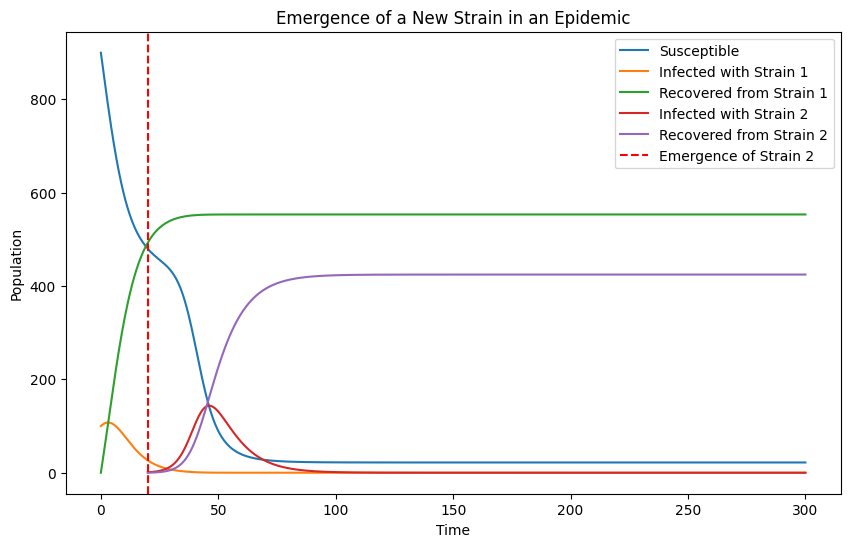

In [5]:
#same params as scenario 1, increasing the initial number of infected with strain 1 to 100
params = [0.42, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [900, 100, 0, 0, 0] # 990 susceptible, 100 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=20)

ne.plot_emergence(t, y)

Variant 2 emerges at t = 20. In this scenario, the starting infected population with variant 1 is 100 people. Because both variants are competing for the same susceptible pool, variant 1 ends up infecting more people (592 vs 475), even though variant 2 has a higher transmission rate ($R_0$ = 7.08 vs 1.27). In total, about 977 people are infected with either strain and 23 are never infected. 

Scenario 3 - Variant 2 emerges and fails to take over

Peak of Strain 1: 278.5182751575474 at time 6.641509433962264
Peak of Strain 2: 1.0 at time 80.0
Total infected with Strain 1: 921.9133639260875
Total infected with Strain 2: 2.1825905324438906


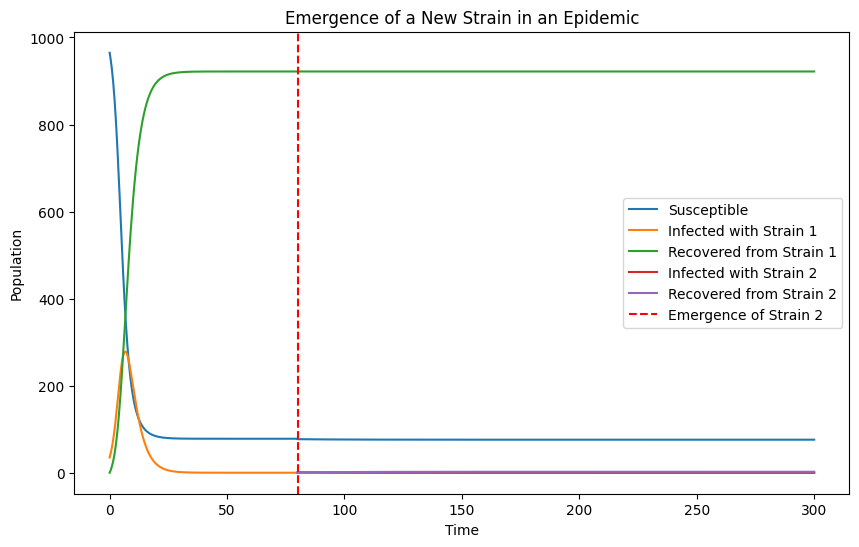

In [7]:
#variant 2 emerges but does not take over
params = [.9, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=80)

ne.plot_emergence(t, y)

Here, the initial infected population is brought back down to 35 while keeping the total population at 1000. The transmission rate for the first variant was increased by a large about (0.42 -> 0.9) and $R_0 =2.73$, which is up from 1.27. Variant 1 infects almost everyone and variant 2 fails to establish. This is because variant 2's reproductive number is less than 1 $(R0₂ × S/N = 7.08 × 56/1,050 = 0.38)$